In [1]:
library(ggplot2)
library(data.table)   # before reshape2: both define melt()
library(reshape2)
library(stringr)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and silently breaks every "+"
# chain, producing a blank PDF. %ni% is inlined from Utilities.R.

`%ni%` <- Negate(`%in%`)

# Terms are keyed by the old module names; they are relabelled only for display.
MODULE_OF_K <- c("0" = "M2", "1" = "M3", "2" = "M6", "3" = "M5", "4" = "M1", "5" = "M4")
moduleLabel <- function(x) {
    for (k in names(MODULE_OF_K)) x <- gsub(paste0("K_?", k), MODULE_OF_K[[k]], x)
    x
}


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt




In [2]:
doubles <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_doublesSameGroup.rds")
doubles <- doubles[doubles$term %ni% c("(Intercept)", "n_genes", "mt_frac", paste0("leiden", 1:9)),]
doubles = data.table(doubles)
doubles[,FDREffect:=p.adjust(p.value, method = "fdr", n = length(p.value)),by=respGene]
doubles = data.frame(doubles)

doubles[,c("estimate","std.error", "statistic", "p.value")] = NULL
doubles$term = sapply(doubles$term, function(x){str_replace_all(x, "_", "")})
doubles = doubles[doubles$term != "K5",] 

doubles[doubles$term == "K0","term"] = 'K0:K0'
doubles[doubles$term == "K1","term"] = 'K1:K1'
doubles[doubles$term == "K2","term"] = 'K2:K2'
doubles[doubles$term == "K3","term"] = 'K3:K3'
doubles[doubles$term == "K4","term"] = 'K4:K4'

#
doubles


,term,respGene,FDREffect
,<chr>,<chr>,<dbl>
1,K0:K0,AI314180,0.7555948782
2,K1:K1,AI314180,0.5077014089
3,K2:K2,AI314180,0.5673572628
4,K3:K3,AI314180,0.5673572628
5,K4:K4,AI314180,0.7555948782
7,K0:K0,Abcc1,0.7052045778
8,K1:K1,Abcc1,0.7052045778
9,K2:K2,Abcc1,0.7052045778
10,K3:K3,Abcc1,0.7052045778


In [3]:
length(unique(doubles$respGene))

[1] 1041

In [4]:
combos <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_lm_residuals.rds")
combos <- combos[combos$term %ni% c("(Intercept)", "n_genes", "mt_frac", paste0("leiden", 1:9)),]
combos = data.table(combos)
combos[,FDR:=p.adjust(p.value, method = "fdr", n = length(p.value)),by=respGene]
combos = data.frame(combos)
combosFDR = copy(combos)

combos = combos[combos$term %ni% c("K_0","K_1","K_2","K_3","K_4","K_5"),]
combos$term = sapply(combos$term, function(x){str_replace_all(x, "W", ":")})
combos$term = sapply(combos$term, function(x){str_replace_all(x, "_", "")})
combos = combos[,c("term", "respGene", "FDR")]
colnames(combos) = c("term", "respGene", "FDREffect")
head(combos)



,term,respGene,FDREffect
,<chr>,<chr>,<dbl>
2,K0:K1,AI314180,0.783263548
3,K0:K2,AI314180,0.942385596
4,K0:K3,AI314180,0.887980223
5,K0:K4,AI314180,0.783263548
6,K0:K5,AI314180,0.717188672
8,K1:K2,AI314180,0.004997751


In [5]:
combos <- rbind(doubles, combos)

head(combos)

,term,respGene,FDREffect
,<chr>,<chr>,<dbl>
1,K0:K0,AI314180,0.7555949
2,K1:K1,AI314180,0.5077014
3,K2:K2,AI314180,0.5673573
4,K3:K3,AI314180,0.5673573
5,K4:K4,AI314180,0.7555949
7,K0:K0,Abcc1,0.7052046


In [6]:
doubleRes <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_doublesResampleRes.rds")
rownames(doubleRes) = doubleRes$respGene
doubleRes = melt(doubleRes, id.vars="respGene")
colnames(doubleRes) = c("respGene","term","FDRInteraction")

combosInterP <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_lm_residuals_withInteractions.rds")
combosInterP <- combosInterP[combosInterP$term %ni% c("(Intercept)", "n_genes", "mt_frac", paste0("leiden", 1:9)),]
combosInterP = data.table(combosInterP)
combosInterP[,FDR:=p.adjust(p.value, method = "fdr", n = length(p.value)),by=respGene]
combosInterP = data.frame(combosInterP)
combosInterP = combosInterP[combosInterP$term %ni% c("K_0","K_1","K_2","K_3","K_4","K_5"),]


combosInterP = combosInterP[,c("respGene","term","FDR")]
colnames(combosInterP) = c("respGene","term","FDRInteraction")
combosInterP$term = sapply(combosInterP$term, function(x){str_replace_all(x, "_", "")})
head(combosInterP)

interEffects = rbind(doubleRes, combosInterP)

,respGene,term,FDRInteraction
,<chr>,<chr>,<dbl>
7,AI314180,K0:K1,0.9370973
8,AI314180,K0:K2,0.7508280
9,AI314180,K0:K3,0.9370973
10,AI314180,K0:K4,0.3049500
11,AI314180,K0:K5,0.4194340
12,AI314180,K1:K2,0.1706959


In [7]:
head(combosInterP)

,respGene,term,FDRInteraction
,<chr>,<chr>,<dbl>
7,AI314180,K0:K1,0.9370973
8,AI314180,K0:K2,0.7508280
9,AI314180,K0:K3,0.9370973
10,AI314180,K0:K4,0.3049500
11,AI314180,K0:K5,0.4194340
12,AI314180,K1:K2,0.1706959


In [8]:
myAll = merge(combos, interEffects, by=c("respGene","term"))
myAll <- myAll[myAll$FDREffect < 0.1,]
myAll$sgnInteraction = FALSE
myAll[myAll$FDRInteraction < 0.1,"sgnInteraction"] = TRUE

In [9]:
table(myAll$term)


K0:K0 K0:K1 K0:K2 K0:K3 K0:K4 K0:K5 K1:K1 K1:K2 K1:K3 K1:K4 K1:K5 K2:K2 K2:K3 
  252   217   299   226   250   175   219   197   235   147   173   163   135 
K2:K4 K2:K5 K3:K3 K3:K4 K3:K5 K4:K4 K4:K5 
  185   112   122   172   119   109    58 

In [10]:
myAll = data.frame(table(myAll[,c("term","sgnInteraction")]))

In [11]:
myAll

term,sgnInteraction,Freq
<fct>,<fct>,<int>
K0:K0,FALSE,10
K0:K1,FALSE,181
K0:K2,FALSE,196
K0:K3,FALSE,123
K0:K4,FALSE,220
K0:K5,FALSE,152
K1:K1,FALSE,13
K1:K2,FALSE,126
K1:K3,FALSE,151


In [12]:
unique(myAll$term)

[1] K0:K0 K0:K1 K0:K2 K0:K3 K0:K4 K0:K5 K1:K1 K1:K2 K1:K3 K1:K4 K1:K5 K2:K2
[13] K2:K3 K2:K4 K2:K5 K3:K3 K3:K4 K3:K5 K4:K4 K4:K5
20 Levels: K0:K0 K0:K1 K0:K2 K0:K3 K0:K4 K0:K5 K1:K1 K1:K2 K1:K3 ... K4:K5

In [13]:
TERM_ORDER <- c(paste0("K", 0:4, ":K", 0:4),                                  # intra-module
                unlist(lapply(0:4, function(i) paste0("K", i, ":K", (i + 1):5))))  # inter-module

myAll$term <- factor(moduleLabel(as.character(myAll$term)),
                     levels = moduleLabel(TERM_ORDER))

agg_record_1308557628 
                    2

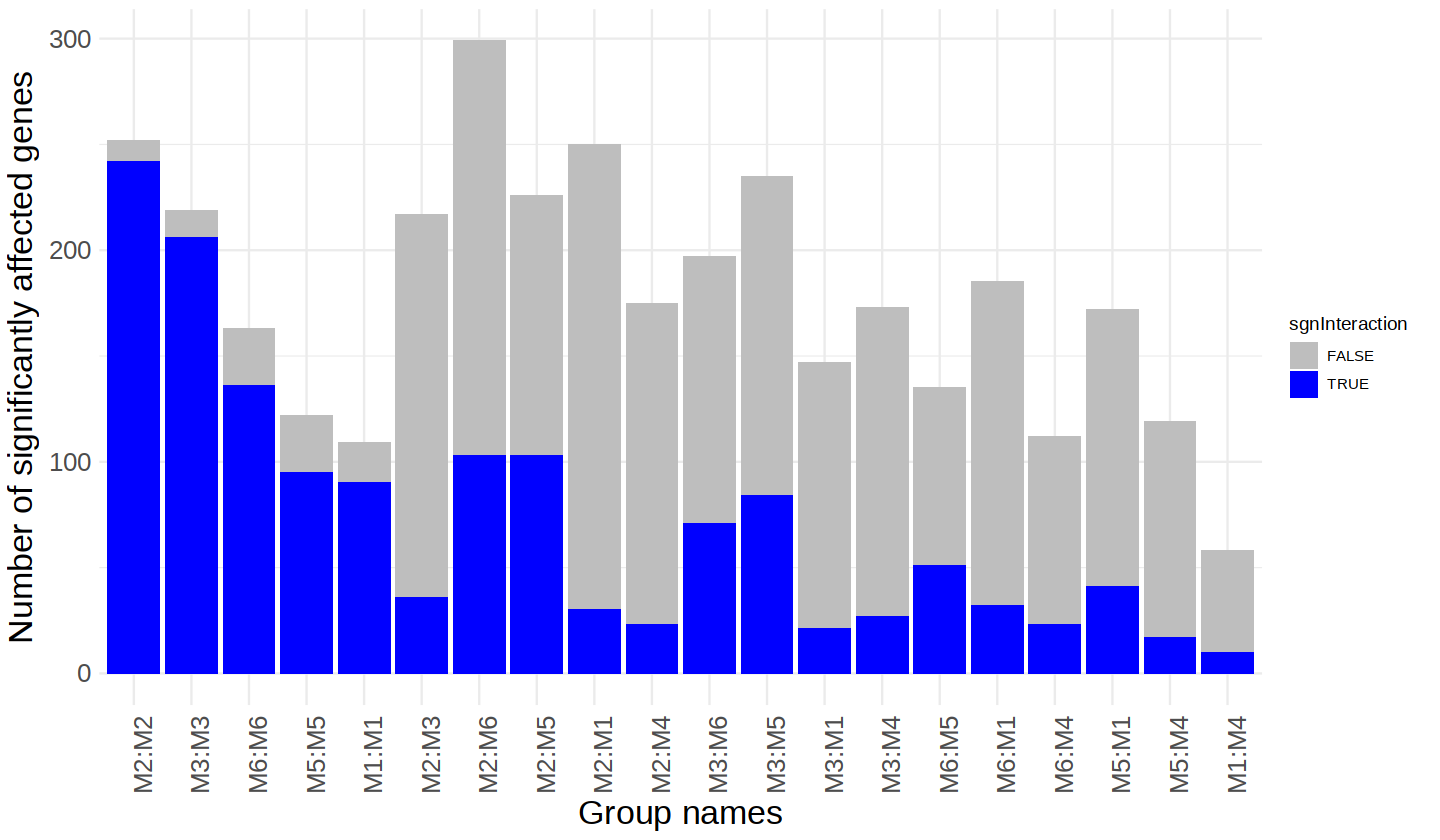

In [14]:
options(repr.plot.width=12, repr.plot.height=7)

p <- ggplot(myAll, aes(fill=sgnInteraction, y=Freq, x=term)) +
    geom_bar(position="stack", stat="identity")+scale_fill_manual(values=c("grey","blue"))+
    ylab("Number of significantly affected genes")+theme_minimal()+
     theme(axis.text.y = element_text(size = 15),
           axis.text.x = element_text(size = 15, angle=90),
              axis.title = element_text(size = 20),
              strip.text = element_text(size = 25))+xlab("Group names")

pdf("figures/Figure_5A.pdf", width=12, height=6)
print(p)
dev.off()

p   # show it in the notebook as well as saving it